# Chapter 10: Visualisation Libraries

## Notes

- Summary statistics are nice but often truly understanding a dataset
  requires *visualising* it
  - One can make data sets with identical summary statistics but that
    look vastly different when visualised
- Python has a number of mature libraries for data visualisation

### Matplotlib

- Matplotlib is the most well-known and used plotting tool in Python
  - Designed for creating publication-ready plots
- Underpin’s many higher-level plotting libraries (See
  [Seaborn](#seaborn))
- Part of the Scipy ecosysem (With
  [NumPy](../Chapter_07/Chapter_07.qmd),
  [Scipy](../Chapter_08/Chapter_08.qmd) and
  [Pandas](../Chapter_09/Chapter_09.qmd))
- Provides several interfaces for use

#### `matplotlib.pylab`

- `pylab` is outdated interface for Matplotlib
- Designed to simulate a MATPLOT environment
- In general it is should not be used anymore

#### `matplotlib.pyplot`

- `pyplot` is the conventional interface for Matplotlib
  - By convention it is imported at `plt`

    ``` python
      import matplotlib.pyplot as plt
    ```
- Matplotlib plots are typically defined in terms of *figures* and
  *axes*
  - A figure represents a graph of data
    - May contain multiple axes
  - Axes are areas where points are specified via coordinates
    - Is associated to *one* figure
- The `pyplot` interface can either be used *implicitly* or *explicitly*
  - plot methods will often implicitly plot to the current axis and
    figure if not otherwise specified
  - For example `plt.plot` is used to plot $x$ vs $y$ data
  - Shown below

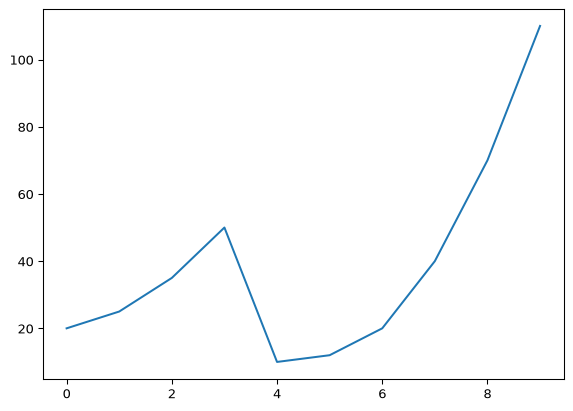

In [1]:
import matplotlib.pyplot as plt
import numpy as np

X = np.arange(0, 10)
Y = np.array([20, 25, 35, 50, 10, 12, 20, 40, 70, 110])

plt.plot(X, Y)

##### Styling Plots

- Plot’s can be further styled at creation time or after creation
- One can directly style a plotted line by interacting directly with the
  `matplotlib.Line2D` class
  - The full list of properties is given in the
    [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.lines.Line2D.html)
  - Alternatively can define these properties as keyword arguments on
    call to `plt.plot`
- Three commonly modified properties are
  1.  `marker`

      - Defines special markers that indicate plotted points

      - Large number of options

        | marker | Description           |
        |--------|-----------------------|
        | .      | point                 |
        | ,      | pixel                 |
        | o      | circle                |
        | v      | upside down triangle  |
        | ^      | up triangle           |
        | \<     | left triangle         |
        | \>     | right triangle        |
        | 1      | tri marker (down)     |
        | 2      | tri marker (up)       |
        | 3      | tri marker (left)     |
        | 4      | tri marker (right)    |
        | s      | square                |
        | p      | pentagon              |
        | \*     | star                  |
        | h      | hexagon               |
        | H      | hexagon (alternative) |
        | \+     | plus                  |
        | D      | diamond               |
        | d      | thin diamond          |
        | \|     | vertical line         |
        | \_     | horizontal line       |

  2.  `linestyle`

      - Defines how the line is styled

        | linestyle            | Description   |
        |----------------------|---------------|
        | \-                   | solid line    |
        | –                    | dashed line   |
        | -.                   | dash dot line |
        | :                    | dotted line   |
        | None or empty string | no line       |

  3.  `color`

      - Colours the line

      - There are simple alias for common colours

        | color | Description |
        |-------|-------------|
        | b     | blue        |
        | g     | green       |
        | r     | red         |
        | c     | cyan        |
        | m     | magenta     |
        | y     | yellow      |
        | k     | black       |
        | w     | white       |
- We can put all this together

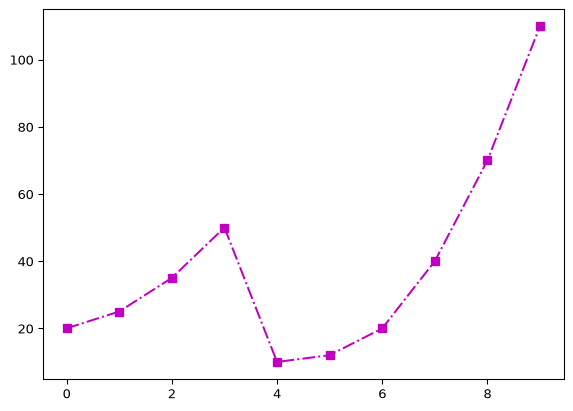

In [2]:
import matplotlib.pyplot as plt
import numpy as np

X = np.arange(0, 10)
Y = np.array([20, 25, 35, 50, 10, 12, 20, 40, 70, 110])

plt.plot(X, Y, marker="s", linestyle="-.", color="m")

- An alternative technique is to use the optional `fmt` positional
  argument
  - Takes a format string
  - This is a shorthand for the marker, line style and colour
  - Structured as `[marker][linestyle][color]`
  - e.g. the equivalent `fmt` string for above is `s-.m`
  - is passed into `plot` after the $x$ and $y$ data

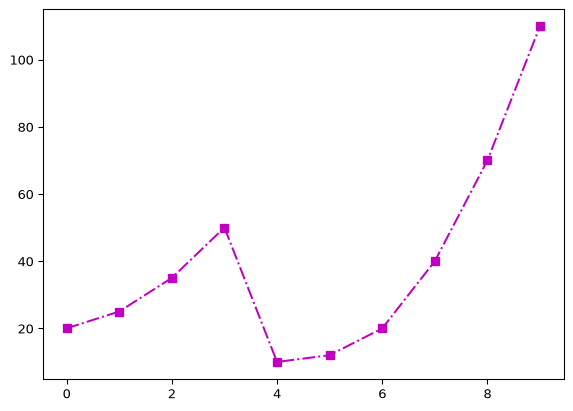

In [3]:
import matplotlib.pyplot as plt
import numpy as np

X = np.arange(0, 10)
Y = np.array([20, 25, 35, 50, 10, 12, 20, 40, 70, 110])

plt.plot(X, Y, "s-.m")

- We can combine the format string specifier with other keyword
  arguments

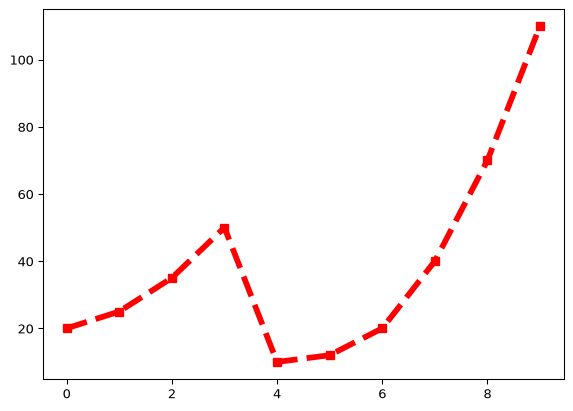

In [4]:
import matplotlib.pyplot as plt
import numpy as np

X = np.arange(0, 10)
Y = np.array([20, 25, 35, 50, 10, 12, 20, 40, 70, 110])

plt.plot(X, Y, "s--r", linewidth=4.3)

##### Labelled Data

- `matplotlib` works with labelled data
  - Integrates nicely with dictionaries, pandas dataframes
  - Extends to any data structure that supports bracket indexing
- Instead of supplying $x$ and $y$ data we supply the labelled data

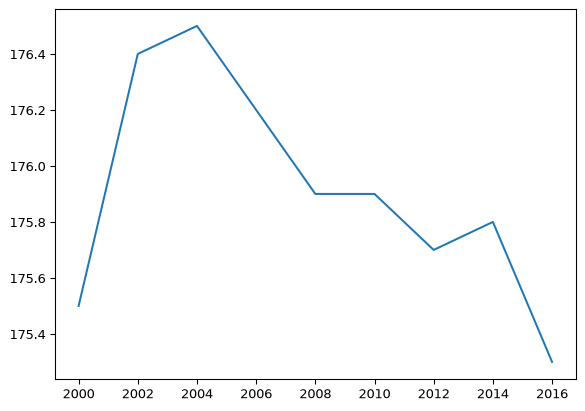

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Years": ["2000", "2002", "2004", "2006", "2008", "2010", "2012", "2014", "2016"],
    "Men": [189.1, 191.8, 193.5, 196.0, 194.7, 196.3, 194.4, 197.0, 197.8],
    "Women": [175.5, 176.4, 176.5, 176.2, 175.9, 175.9, 175.7, 175.8, 175.3],
}

heights_df = pd.DataFrame(data)
plt.plot("Years", "Women", data=heights_df)

- Observe here rather than pass the $x$ and $y$ we pass the labels as
  mentioned, then supply the dataframe via the `data` parameter

##### Plotting Multiple Sets of Data

- Multiple datasets can be plotted on the same figure
- Most straightforward approach is just to call `plot` multiple times

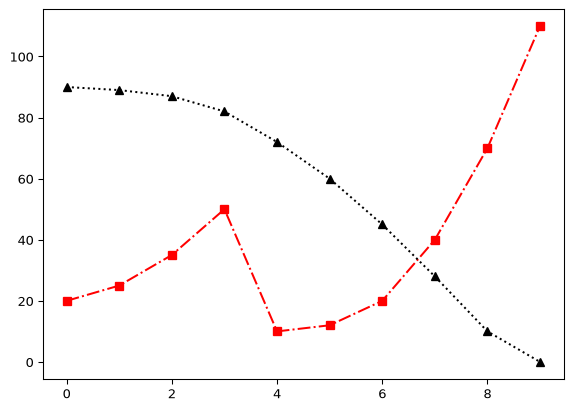

In [6]:
import matplotlib.pyplot as plt
import numpy as np

X_1 = np.arange(0, 10)
Y_1 = np.array([20, 25, 35, 50, 10, 12, 20, 40, 70, 110])
fmt = "s-.r"

X_2 = np.arange(0, 10)
Y_2 = np.array([90, 89, 87, 82, 72, 60, 45, 28, 10, 0])
fmt2 = "^:k"

plt.plot(X_1, Y_1, fmt)
plt.plot(X_2, Y_2, fmt2)

- This works because `plot` defaults to the current figure and axes
  - As long as we haven’t cleared the previous figure it will continue
    to layer onto the current figure
- The alternative is to pass everything in one go (each block of $x$,
  $y$, `fmt` sequentially)

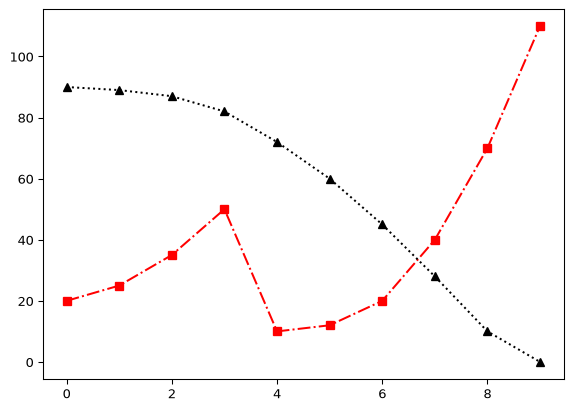

In [7]:
import matplotlib.pyplot as plt
import numpy as np

X_1 = np.arange(0, 10)
Y_1 = np.array([20, 25, 35, 50, 10, 12, 20, 40, 70, 110])
fmt = "s-.r"

X_2 = np.arange(0, 10)
Y_2 = np.array([90, 89, 87, 82, 72, 60, 45, 28, 10, 0])
fmt2 = "^:k"

plt.plot(X_1, Y_1, fmt, X_2, Y_2, fmt2)

- We can do the same with labelled data by passing additional labels

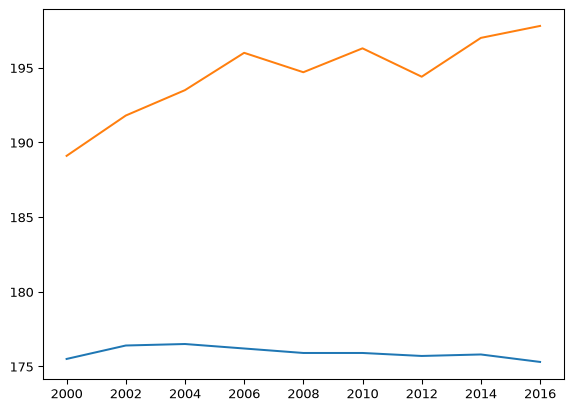

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Years": ["2000", "2002", "2004", "2006", "2008", "2010", "2012", "2014", "2016"],
    "Men": [189.1, 191.8, 193.5, 196.0, 194.7, 196.3, 194.4, 197.0, 197.8],
    "Women": [175.5, 176.4, 176.5, 176.2, 175.9, 175.9, 175.7, 175.8, 175.3],
}

heights_df = pd.DataFrame(data)
plt.plot("Years", "Women", "Men", data=heights_df)

##### Adding Labels, Titles and Legends

- `pyplot` provides simple convenience functions for adding labels,
  titles and legends
- As with `plot` these applyt to the current figure and axes

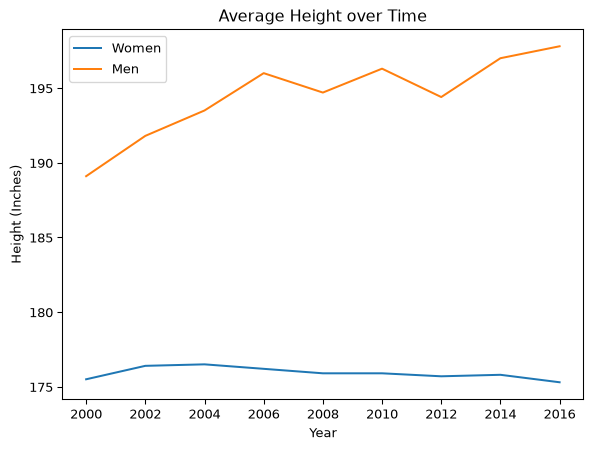

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Years": ["2000", "2002", "2004", "2006", "2008", "2010", "2012", "2014", "2016"],
    "Men": [189.1, 191.8, 193.5, 196.0, 194.7, 196.3, 194.4, 197.0, 197.8],
    "Women": [175.5, 176.4, 176.5, 176.2, 175.9, 175.9, 175.7, 175.8, 175.3],
}

heights_df = pd.DataFrame(data)
plt.plot("Years", "Women", "Men", data=heights_df)
plt.xlabel("Year")
plt.ylabel("Height (Inches)")
plt.title("Average Height over Time")
plt.legend(["Women", "Men"])

#### Axes Interface or Object-Oriented Style

- The second main interface for Matplotlib is the Axes interface
- Also referred to as the Object-Oriented interface
- Contrasts the implicit or functional interface of pyplot
  - Interactive interface tends to be more useful in interactive data
    interrogation
  - Very popular in combination with jupyter notebooks
- The axes interface let’s you directly interact with figures and axes
  to have more fine-grained control over how plot’s look
  - Can be accessed directly via the figure and axes elements
  - Or via some `pyplot` functions like `pyplot.subplots`
    - Return’s a figure and a the specified number of axes (by default
      $1$)
    - Each axes can then be plotted on directly like with the implicit
      interface

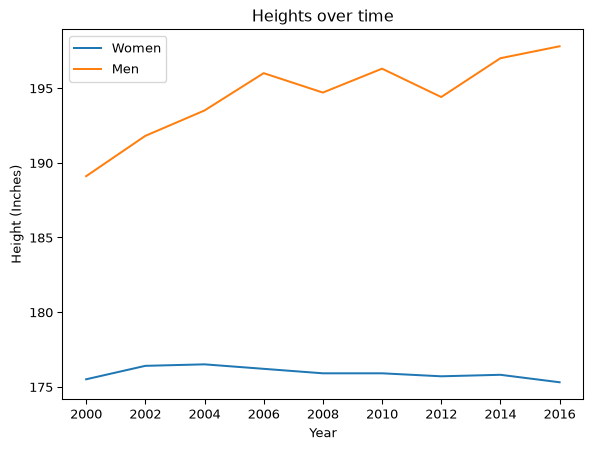

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Years": ["2000", "2002", "2004", "2006", "2008", "2010", "2012", "2014", "2016"],
    "Men": [189.1, 191.8, 193.5, 196.0, 194.7, 196.3, 194.4, 197.0, 197.8],
    "Women": [175.5, 176.4, 176.5, 176.2, 175.9, 175.9, 175.7, 175.8, 175.3],
}

heights_df = pd.DataFrame(data)

# Get one figure and axis
fig, ax = plt.subplots()
ax.plot("Years", "Women", "Men", data=heights_df)
ax.set_xlabel("Year")
ax.set_ylabel("Height (Inches)")
ax.set_title("Heights over time")
ax.legend(["Women", "Men"])

- Using multiple axes enables plotting multiple charts on the same
  figure
- Use `plt.subplots`, specify the *shape* of the plot in terms of the
  number of rows, then columns
- For example, plotting two charts

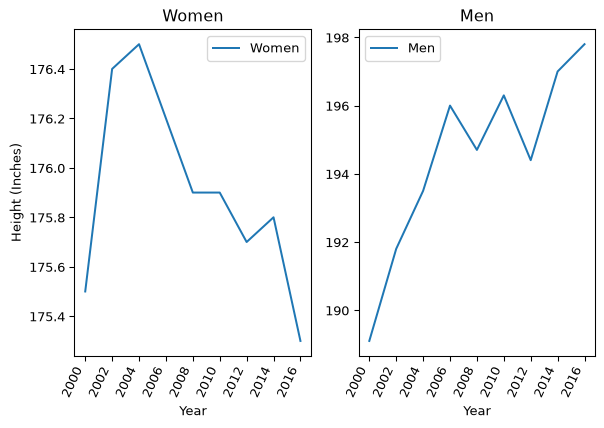

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Years": ["2000", "2002", "2004", "2006", "2008", "2010", "2012", "2014", "2016"],
    "Men": [189.1, 191.8, 193.5, 196.0, 194.7, 196.3, 194.4, 197.0, 197.8],
    "Women": [175.5, 176.4, 176.5, 176.2, 175.9, 175.9, 175.7, 175.8, 175.3],
}

heights_df = pd.DataFrame(data)

fig, (ax1, ax2) = plt.subplots(1, 2)  # Create a figure with 1 row and 2 columns

ax1.plot("Years", "Women", data=heights_df)
ax1.set_xlabel("Year")
ax1.set_ylabel("Height (Inches)")
ax1.set_title("Women")
ax1.legend(["Women"])

ax2.plot("Years", "Men", data=heights_df)
ax2.set_xlabel("Year")
ax2.set_title("Men")
ax2.legend(["Men"])

fig.autofmt_xdate(rotation=65)  # Rotate data labels

- This explicit style is great once you’re looking to create polished
  finished charts instead of just general interactive data interrogation

### Seaborn

- Seaborn is a statistical plotting library

  - Designed to be used with Pandas
  - Builds on top of [Matplotlib](#matplotlib)
  - Aims to provide good-looking plots out of the box

- By convention Seaborn is imported as `sns`

  ``` python
    import seaborn as sns
  ```

- Seaborn comes with some built-in datasets

  - Used in the online documentation and tutorials
  - Aims to give you something to work with out of the box

- Datasets are designed to be loaded as Pandas dataframes

  - The full list is maintained at ths
    [repository](https://github.com/mwaskom/seaborn-data)

- For example, plotting some data from the car crashes dataset

  - Here the relationship between two columns using the `relplot`

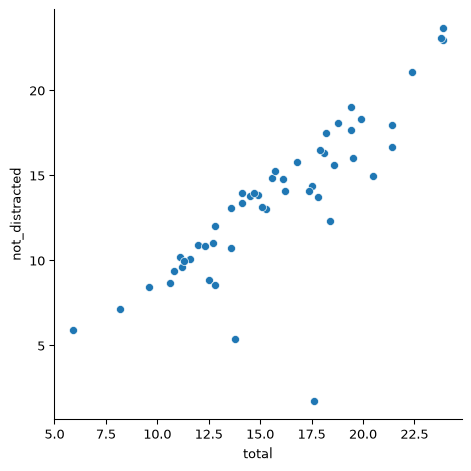

In [12]:
import seaborn as sns

car_crashes = sns.load_dataset("car_crashes")
car_crashes = car_crashes[["total", "not_distracted", "alcohol"]] #filtering the dataframe
sns.relplot(data=car_crashes, x="total", y="not_distracted")

#### Seaborn Themes

- Seaborn bundles a number of themes that control how plots are styled

- The default is set via

  ``` python
    sns.set_theme()
  ```

- We can repeat our previous plot to see the style of this theme

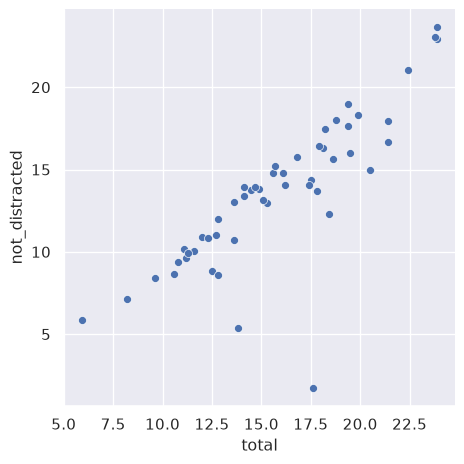

In [13]:
import seaborn as sns

sns.set_theme()

car_crashes = sns.load_dataset("car_crashes")
car_crashes = car_crashes[
    ["total", "not_distracted", "alcohol"]
]  # filtering the dataframe
sns.relplot(data=car_crashes, x="total", y="not_distracted")

- A seaborn theme changes a bunch of parameters behind the scenes

- The theme thus applied to any subsequent seaborn themes

  - But is also applied to general Matplotlib plots too!

- Seaborn breaks down formatting a chart into two types of parameters

  1.  Style
      - The aesthetic
  2.  Scale
      - The sizing of the plot and various elements

- Seaborn also defines a number of *styles* that can be set

  - There are five included by default

    1.  `darkgrid`
    2.  `whitegrid`
    3.  `dark`
    4.  `white`
    5.  `ticks`

- Style is then set by `sns.set_style`

- For example, using the dark style

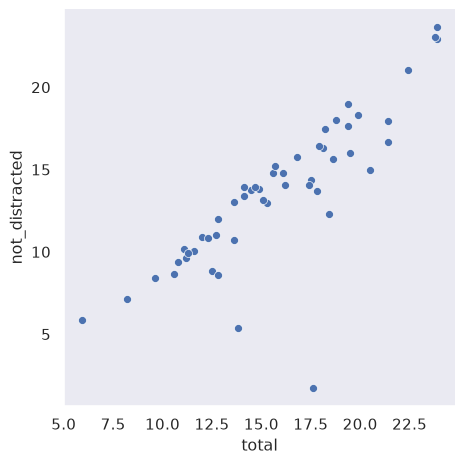

In [14]:
import seaborn as sns

sns.set_style("dark")

car_crashes = sns.load_dataset("car_crashes")
car_crashes = car_crashes[
    ["total", "not_distracted", "alcohol"]
]  # filtering the dataframe
sns.relplot(data=car_crashes, x="total", y="not_distracted")

- Setting the scale is designed to target specific presentation styles.
  The defaults are

  1.  `paper`
  2.  `notebook`
  3.  `talk`
  4.  `poster`

- The scale theme can be set via the `set_context` instructions

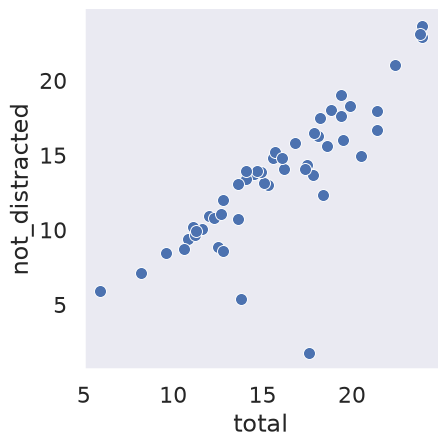

In [15]:
import seaborn as sns

sns.set_context("talk")

car_crashes = sns.load_dataset("car_crashes")
car_crashes = car_crashes[
    ["total", "not_distracted", "alcohol"]
]  # filtering the dataframe
sns.relplot(data=car_crashes, x="total", y="not_distracted")

#### Seaborn Plot Types

- Seaborn has an extension range of different plots
- One useful class is `pairplot`
  - Helps identify correlations in data
  - Plot’s the correlations between all columns in a dataframe
- For example, using the Iris built-in dataset

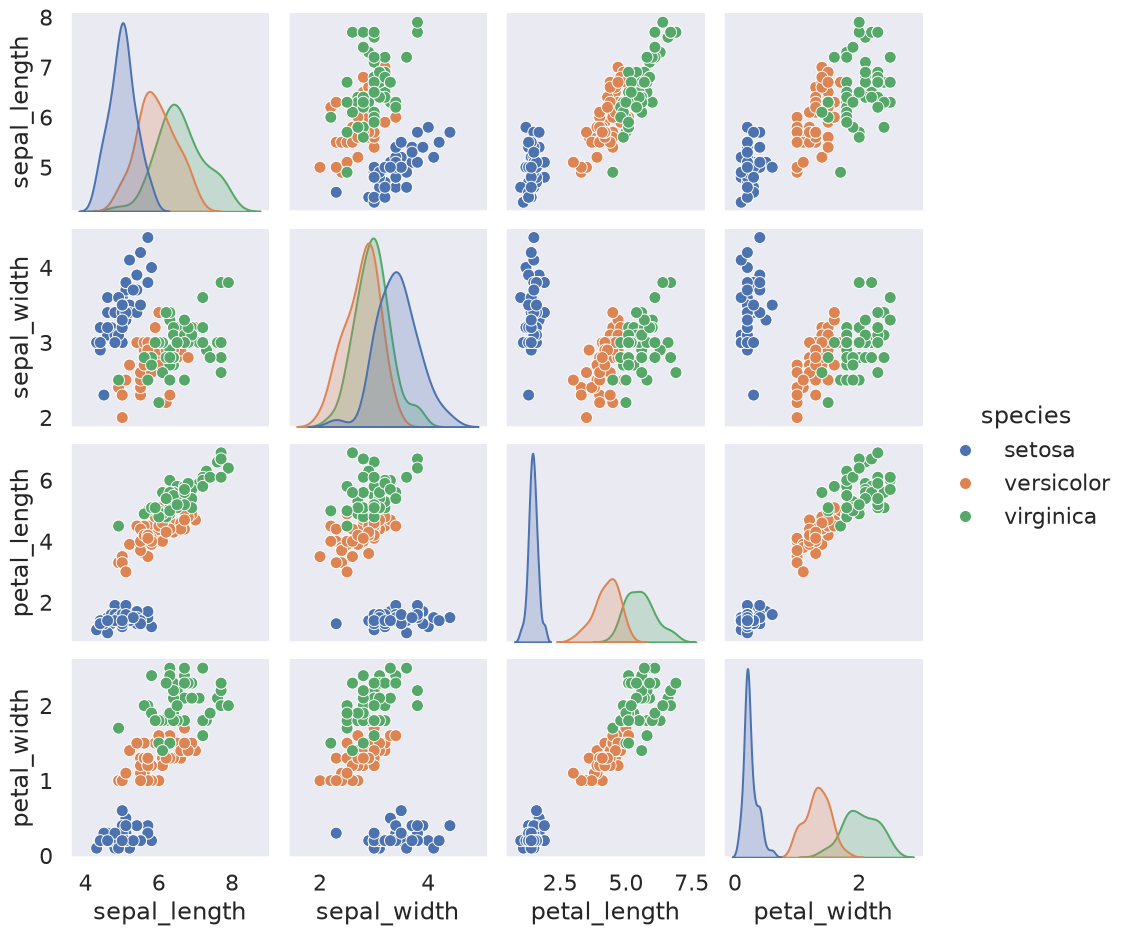

In [16]:
import seaborn as sns

df = sns.load_dataset("iris")
sns.pairplot(df, hue="species")

### Plotly

- [Matplotlib](#matplotlib) and by extension [Seaborn](#seaborn) are
  designed primarily for publication-ready static charts
  - Or simple animations
- They can be extended to create interactive charts, but not their
  primary supported use case
- Plotly is designed for producing high-quality interactive charts
- An advantage of Plotly over Matplotlib is that it supports a proper 3D
  rendering engine for 3D plots
- For example, the chart below demonstrates a 3D plot created in Plotly

In [17]:
import plotly.express as px

iris = px.data.iris()

fig = px.scatter_3d(
    iris, x="sepal_length", y="petal_width", z="petal_length", color="species"
)
fig.show()

### Bokeh

- Bokeh is another library for creating interactive plots
- Designed to offer improved performance and enable data to be updated
  without a state reload via the `ColumnDataSource` class
- Data sources can be shared across figures
  - Means updating the data source automatically updates dependent plots

In [18]:
from bokeh.io import output_notebook
from bokeh.plotting import figure, show
from boken.models import ColumnDataSource
from bokeh.layouts import gridplot

output_notebook()

Y_1 = [x for x in range(0, 200, 2)]
Y_2 = [x**2 for x in Y]

X = [x for x in range(100)]

data = {"x": X, "y1": Y_1, "y2": Y_2}  # create data

TOOLS = "box_select"  # select interactive tools
source = ColumnDataSource(data=data)  # Create data model

left = figure(tools=TOOLS, title="Brushing")  # Create figure using the selected tools
left.circle("x", "y", source=source)  # Create a circle plot on the first figure

right = figure(
    tools=TOOLS, title="Brushing"
)  # Create a second figure using the selected tools
right.circle("x", "y1", source=source)  # Create a circle plot on the second figure

p = gridplot([[left, right]])  # Put the figures on a grid
show(p)  # Show the grid

- The resulting figures can be selected cross-axes
  - Defined by the specified tool
- Selecting one plot, selects the corresponding points on the other
  chart

### Other Visualisation Libraries

- There are a range of other visualisation suites available

- Most cater to specific domains or data regimes

  - `geoplotlib`
    - For visualising maps and geographic data
  - `ggplot`
    - Python interface based on the R package ggplot2
  - `pygal`
    - For creating simple plots
  - `folium`
    - For creating interactive maps
  - `missingno`
    - Enables visualising missing data

## Summary

- Visualisation is highly important for data exploration and data
  presentation
- Many libraries exist for visualising data
  - Different libraries cater to different domains
- `matplotlib` is the plotting library as part of the Scipy suite
  - Underpins many other high level plotting libraries
  - Very common in scientific communication and publication-ready
    presentation
  - Very powerful but can have a steep learning curve
- `seaborn` is a statistics visualisation library built on `matplotlib`
  - It is designed for making it easy to plot standard statistical plots
    out of the box
- `Plotly` and `Bokeh` are other plotting engines designed for creating
  more interactive visualisations
  - Also great for creating dashboards

## Questions

Use the following example to answer the following questions

``` python
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = {
    "X": [x for x in range(50)],
    "Y": [y for y in range(50, 0, -1)],
    "Y1": [y**2 for y in range(25, 75)]
}

df = pd.DataFrame(data)
```

1.  Use `matplotlib` to plot the relationship between column `X` and
    column `Y`
    - See below
2.  Use `matplotlib` to plot the relationship between column `X` and
    column `Y1` to the same plot
    - See below
3.  Use `matplotlib` to plot the relationship betweeen the relationships
    from Question 1 and Question 2 on seperate axes of the same figure
    - See below
4.  Use `seaborn` to change the theme to `darkgrid` and then repeat the
    plots from Question 3

Question 1

Text(0, 0.5, 'Y')

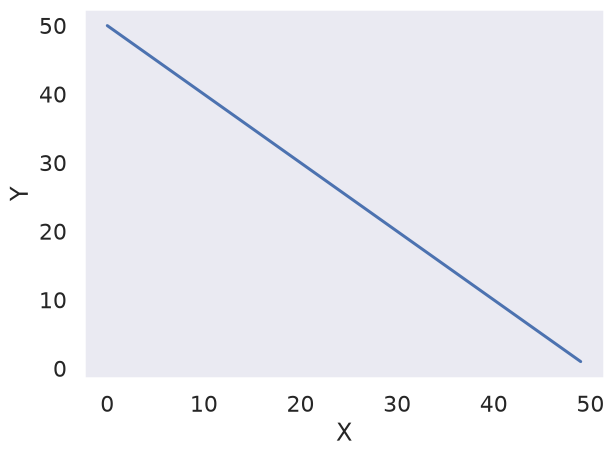

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = {
    "X": [x for x in range(50)],
    "Y": [y for y in range(50, 0, -1)],
    "Y1": [y**2 for y in range(25, 75)],
}

df = pd.DataFrame(data)

print("Question 1")
plt.plot("X", "Y", data=data)
plt.xlabel("X")
plt.ylabel("Y")

Question 2

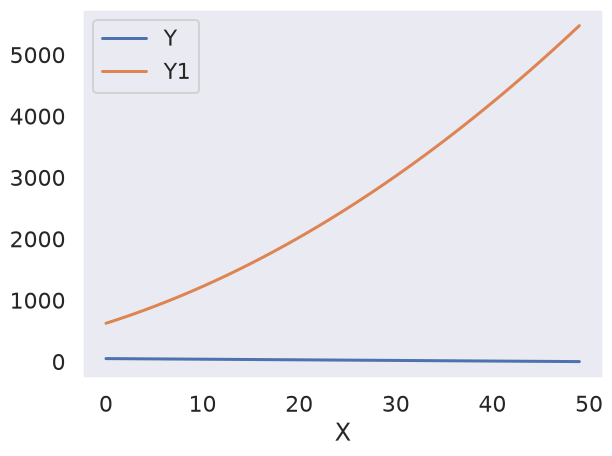

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = {
    "X": [x for x in range(50)],
    "Y": [y for y in range(50, 0, -1)],
    "Y1": [y**2 for y in range(25, 75)],
}

df = pd.DataFrame(data)

print("Question 2")
plt.plot("X", "Y", "Y1", data=data)
plt.xlabel("X")
plt.legend(["Y", "Y1"])

Question 3

Text(0, 0.5, 'Y')

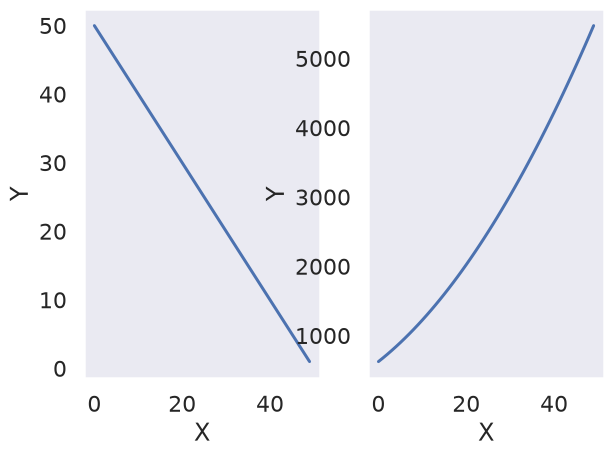

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = {
    "X": [x for x in range(50)],
    "Y": [y for y in range(50, 0, -1)],
    "Y1": [y**2 for y in range(25, 75)],
}
df = pd.DataFrame(data)

print("Question 3")
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot("X", "Y", data=data)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")


ax2.plot("X", "Y1", data=data)
ax2.set_xlabel("X")
ax2.set_ylabel("Y")

Question 4

Text(0, 0.5, 'Y')

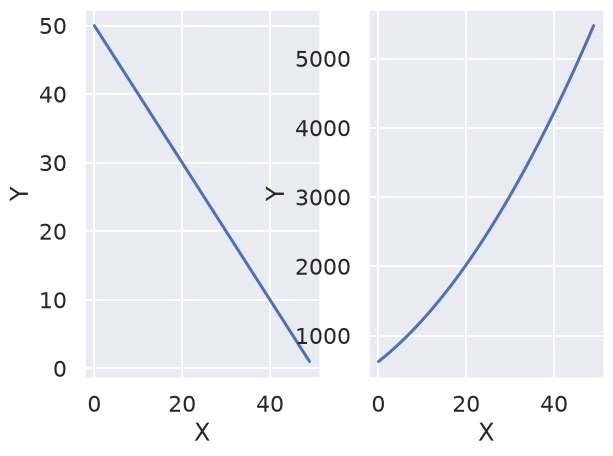

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = {
    "X": [x for x in range(50)],
    "Y": [y for y in range(50, 0, -1)],
    "Y1": [y**2 for y in range(25, 75)],
}
df = pd.DataFrame(data)

print("Question 4")

sns.set_style("darkgrid")

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot("X", "Y", data=data)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")


ax2.plot("X", "Y1", data=data)
ax2.set_xlabel("X")
ax2.set_ylabel("Y")